# Similitud entre historias usando Word2Vec

Comparamos las historias de dos libros de cuentos de hadas utilizando **Word2Vec** para representar cada cuento como un vector y luego medir la **similitud coseno** entre ellos.

| Libro | Título | Autor |
|-------|--------|-------|
| 1 | *The Blue Fairy Book* | Andrew Lang |
| 2 | *Indian Fairy Tales* | Joseph Jacobs |

In [2]:
# Instalar dependencias necesarias
%pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.2 MB/s eta 0:00:00:00:0100:01


In [3]:
import urllib.request
import re
import numpy as np
import nltk

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

stop_words = set(stopwords.words('english'))

print('Dependencias cargadas correctamente.')

Dependencias cargadas correctamente.


In [ ]:
def download_book(url):
    """Descarga un libro de Project Gutenberg y retorna su texto limpio."""
    with urllib.request.urlopen(url) as response:
        text = response.read().decode('utf-8')

    # Normalizar saltos de línea
    text = text.replace('\r\n', '\n')

    # Eliminar encabezado y pie de Project Gutenberg
    start = re.search(r'\*\*\* START OF.*?\*\*\*', text)
    end   = re.search(r'\*\*\* END OF.*?\*\*\*', text)
    if start: text = text[start.end():]
    if end:   text = text[:end.start()]
    return text.strip()

url_book1 = 'https://www.gutenberg.org/cache/epub/503/pg503.txt'
url_book2 = 'https://www.gutenberg.org/cache/epub/7128/pg7128.txt'

raw_book1 = download_book(url_book1)
raw_book2 = download_book(url_book2)

print(f'Libro 1 descargado: {len(raw_book1):,} caracteres')
print(f'Libro 2 descargado: {len(raw_book2):,} caracteres')

870
945
Libro 1 descargado: 731,428 caracteres
Libro 2 descargado: 388,088 caracteres


## Paso 1 — Separar cada libro en historias individuales

Cada libro es una colección de cuentos. Identificamos los títulos y separamos el texto de cada historia.

In [ ]:
# ── Libro 1: The Blue Fairy Book ──
# Los títulos de las historias están en MAYÚSCULAS, en su propia línea,
# rodeados de líneas en blanco.

# Títulos conocidos del libro (extraídos de la tabla de contenido)
titles_book1 = [
    'THE BRONZE RING',
    'PRINCE HYACINTH AND THE DEAR LITTLE PRINCESS',
    'EAST OF THE SUN AND WEST OF THE MOON',
    'THE YELLOW DWARF',
    'LITTLE RED RIDING HOOD',
    'THE SLEEPING BEAUTY IN THE WOOD',
    'CINDERELLA, OR THE LITTLE GLASS SLIPPER',
    'ALADDIN AND THE WONDERFUL LAMP',
    'THE TALE OF A YOUTH WHO SET OUT TO LEARN WHAT FEAR WAS',
    'RUMPELSTILTZKIN',
    'BEAUTY AND THE BEAST',
    'THE MASTER-MAID',
    'WHY THE SEA IS SALT',
    'THE MASTER CAT; OR, PUSS IN BOOTS',
    'FELICIA AND THE POT OF PINKS',
    'THE WHITE CAT',
    'THE TERRIBLE HEAD',
    'THE STORY OF PRETTY GOLDILOCKS',
    'THE HISTORY OF WHITTINGTON',
    'THE WONDERFUL SHEEP',
    'LITTLE THUMB',
    'THE FORTY THIEVES',
    'HANSEL AND GRETTEL',
    'SNOW-WHITE AND ROSE-RED',
    'THE GOOSE-GIRL',
    'TOADS AND DIAMONDS',
    'PRINCE DARLING',
    'BLUE BEARD',
    'TRUSTY JOHN',
    'THE BRAVE LITTLE TAILOR',
    'A VOYAGE TO LILLIPUT',
    'THE PRINCESS ON THE GLASS HILL',
    'THE STORY OF PRINCE AHMED AND THE FAIRY PARIBANOU',
    'THE HISTORY OF JACK THE GIANT-KILLER',
    'THE BLACK BULL OF NORROWAY',
    'THE RED ETIN',
]

# Títulos conocidos del libro 2: Indian Fairy Tales
# (los títulos aparecen en Title Case en el cuerpo del texto)
titles_book2 = [
    'The Lion and the Crane',
    "How the Raja's Son won the Princess Labam.",
    'The Lambikin',
    'Punchkin',
    'The Broken Pot',
    'The Magic Fiddle',
    'The Cruel Crane Outwitted',
    'Loving Laili',
    'The Tiger, the Brahman, and the Jackal',
    'The Soothsayer\'s Son',
    'The Charmed Ring',
    'The Talkative Tortoise',
    'A Lac of Rupees for a Bit of Advice',
    'The Gold-giving Serpent',
    'The Son of Seven Queens',
    'A Flower\'s Story',
    'The Ass in the Lion\'s Skin',
    'The Farmer and the Money-lender',
    'The Boy who had a Moon on his Forehead and a Star on his Chin',
    'Pride Goeth before a Fall',
    'Raja Doeth before a Fall',
    'The Jackal and the Partridge',
    'The Demon with the Matted Hair',
]


def split_by_titles(text, titles_list):
    """
    Separa un texto en historias basándose en una lista de títulos conocidos.
    Busca cada título como línea independiente en el texto.
    """
    lines = text.split('\n')
    # Encontrar la posición de cada título en el texto
    title_positions = []
    for i, line in enumerate(lines):
        stripped = line.strip()
        for title in titles_list:
            if stripped.upper() == title.upper():
                title_positions.append((i, title.title()))
                break

    # Extraer el contenido entre títulos
    stories = {}
    for idx, (line_num, title) in enumerate(title_positions):
        # El contenido va desde la línea siguiente al título hasta el próximo título
        start = line_num + 1
        end = title_positions[idx + 1][0] if idx + 1 < len(title_positions) else len(lines)
        body = '\n'.join(lines[start:end]).strip()
        if len(body) > 200:  # ignorar secciones muy cortas
            stories[title] = body

    return stories


stories_book1 = split_by_titles(raw_book1, titles_book1)
stories_book2 = split_by_titles(raw_book2, titles_book2)

print(f'The Blue Fairy Book: {len(stories_book1)} historias')
for i, title in enumerate(stories_book1, 1):
    print(f'  {i:>2}. {title}')

print(f'\nIndian Fairy Tales: {len(stories_book2)} historias')
for i, title in enumerate(stories_book2, 1):
    print(f'  {i:>2}. {title}')

The Blue Fairy Book: 36 historias
   1. The Bronze Ring
   2. Prince Hyacinth And The Dear Little Princess
   3. East Of The Sun And West Of The Moon
   4. The Yellow Dwarf
   5. Little Red Riding Hood
   6. The Sleeping Beauty In The Wood
   7. Cinderella, Or The Little Glass Slipper
   8. Aladdin And The Wonderful Lamp
   9. The Tale Of A Youth Who Set Out To Learn What Fear Was
  10. Rumpelstiltzkin
  11. Beauty And The Beast
  12. The Master-Maid
  13. Why The Sea Is Salt
  14. The Master Cat; Or, Puss In Boots
  15. Felicia And The Pot Of Pinks
  16. The White Cat
  17. The Terrible Head
  18. The Story Of Pretty Goldilocks
  19. The History Of Whittington
  20. The Wonderful Sheep
  21. Little Thumb
  22. The Forty Thieves
  23. Hansel And Grettel
  24. Snow-White And Rose-Red
  25. The Goose-Girl
  26. Toads And Diamonds
  27. Prince Darling
  28. Blue Beard
  29. Trusty John
  30. The Brave Little Tailor
  31. A Voyage To Lilliput
  32. The Princess On The Glass Hill
  33. The 

## Paso 2 — Tokenización y limpieza

Convertimos cada historia en una lista de tokens (sin stopwords, sin puntuación, mínimo 3 caracteres).

In [11]:
def tokenize_story(text):
    """Tokeniza y limpia una historia."""
    tokens = nltk.word_tokenize(text.lower())
    return [
        t for t in tokens
        if t.isalpha() and t not in stop_words and len(t) > 2
    ]

tokenized_book1 = {title: tokenize_story(body) for title, body in stories_book1.items()}
tokenized_book2 = {title: tokenize_story(body) for title, body in stories_book2.items()}

print('Ejemplo de tokens (primera historia de cada libro):\n')
for name, tok_dict in [('Blue Fairy Book', tokenized_book1), ('Indian Fairy Tales', tokenized_book2)]:
    if tok_dict:
        first_title = list(tok_dict.keys())[0]
        print(f'{name} — "{first_title}":')
        print(f'  Primeros 15 tokens: {tok_dict[first_title][:15]}')
        print(f'  Total tokens: {len(tok_dict[first_title])}\n')

Ejemplo de tokens (primera historia de cada libro):

Blue Fairy Book — "The Bronze Ring":
  Primeros 15 tokens: ['upon', 'time', 'certain', 'country', 'lived', 'king', 'whose', 'palace', 'surrounded', 'spacious', 'garden', 'though', 'gardeners', 'many', 'soil']
  Total tokens: 1710

Indian Fairy Tales — "The Lion And The Crane":
  Primeros 15 tokens: ['bodhisatta', 'one', 'time', 'born', 'region', 'himavanta', 'white', 'crane', 'brahmadatta', 'time', 'reigning', 'benares', 'chanced', 'lion', 'eating']
  Total tokens: 190



## Paso 3 — Entrenar Word2Vec

Entrenamos un modelo Word2Vec con **todas las historias de ambos libros** para obtener representaciones vectoriales compartidas.

In [12]:
all_tokenized = list(tokenized_book1.values()) + list(tokenized_book2.values())

model = Word2Vec(
    sentences=all_tokenized,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=50,
    seed=42
)

print(f'Modelo Word2Vec entrenado.')
print(f'  Vocabulario: {len(model.wv)} palabras')
print(f'  Historias utilizadas: {len(all_tokenized)}')

Modelo Word2Vec entrenado.
  Vocabulario: 5430 palabras
  Historias utilizadas: 56


## Paso 4 — Vectorizar historias y calcular similitud coseno

Representamos cada historia como el **promedio de los vectores de sus palabras** y luego calculamos la similitud coseno entre cada par (una historia de cada libro).

In [13]:
def story_vector(tokens, wv_model):
    """Calcula el vector promedio de una historia."""
    vectors = [wv_model.wv[t] for t in tokens if t in wv_model.wv]
    if not vectors:
        return np.zeros(wv_model.wv.vector_size)
    return np.mean(vectors, axis=0)

vectors_book1 = {t: story_vector(tok, model) for t, tok in tokenized_book1.items()}
vectors_book2 = {t: story_vector(tok, model) for t, tok in tokenized_book2.items()}

results = []
for t1, v1 in vectors_book1.items():
    for t2, v2 in vectors_book2.items():
        sim = cosine_similarity([v1], [v2])[0][0]
        results.append((t1, t2, sim))

results.sort(key=lambda x: x[2], reverse=True)

print(f'Se compararon {len(vectors_book1)} × {len(vectors_book2)} = {len(results)} pares de historias.')

Se compararon 36 × 20 = 720 pares de historias.


## Paso 5 — Top 5 historias más similares

In [14]:
print(f'{"#":<4} {"Historia (Blue Fairy Book)":<45} {"Historia (Indian Fairy Tales)":<45} {"Similitud":>10}')
print('─' * 108)

for i, (t1, t2, sim) in enumerate(results[:5], 1):
    print(f'{i:<4} {t1:<45} {t2:<45} {sim:>10.4f}')

print('\n✅ Estas son las 5 historias con mayor similitud según Word2Vec.')

#    Historia (Blue Fairy Book)                    Historia (Indian Fairy Tales)                  Similitud
────────────────────────────────────────────────────────────────────────────────────────────────────────────
1    The Bronze Ring                               The Charmed Ring                                  0.9138
2    The Sleeping Beauty In The Wood               The Son Of Seven Queens                           0.9078
3    The Sleeping Beauty In The Wood               Punchkin                                          0.9055
4    The White Cat                                 The Son Of Seven Queens                           0.8878
5    The Bronze Ring                               The Boy Who Had A Moon On His Forehead And A Star On His Chin     0.8857

✅ Estas son las 5 historias con mayor similitud según Word2Vec.


## Visualización

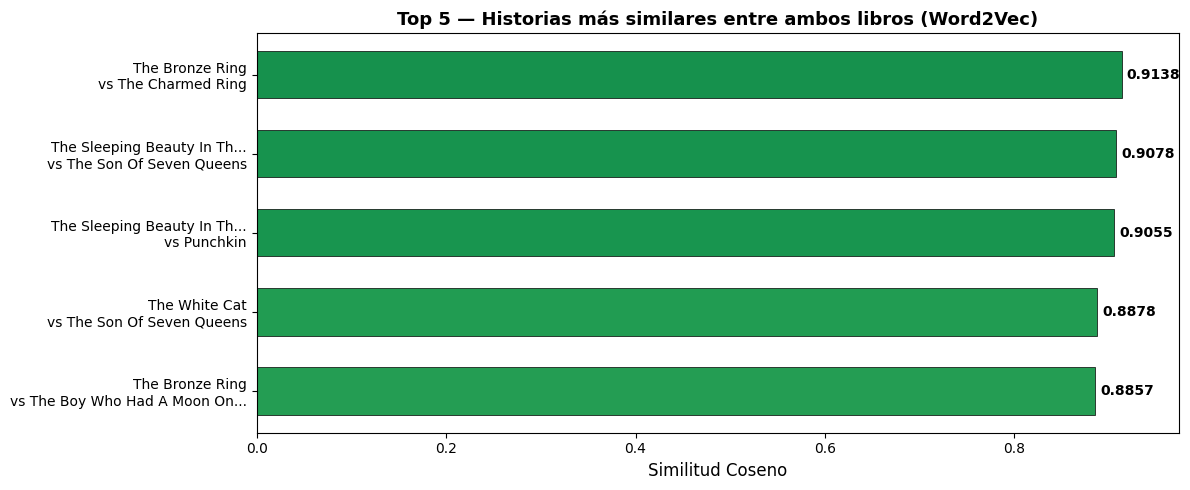

In [15]:
import matplotlib.pyplot as plt

top5 = results[:5]
labels = []
for t1, t2, _ in top5:
    l1 = t1 if len(t1) <= 28 else t1[:25] + '...'
    l2 = t2 if len(t2) <= 28 else t2[:25] + '...'
    labels.append(f'{l1}\nvs {l2}')

sims = [s for _, _, s in top5]

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.RdYlGn(sims)
bars = ax.barh(labels[::-1], sims[::-1], color=colors[::-1],
               edgecolor='black', linewidth=0.5, height=0.6)

for bar, sim in zip(bars, sims[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{sim:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Similitud Coseno', fontsize=12)
ax.set_title('Top 5 — Historias más similares entre ambos libros (Word2Vec)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, max(sims) + 0.06)
plt.tight_layout()
plt.show()